In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_excel("heart_disease.xlsx", sheet_name=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [20]:
df.shape

(908, 13)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 92.3+ KB


In [22]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

### Handle Missing Values

In [23]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [24]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [25]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,908.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,4,3,NaN,4,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,normal,NaN
freq,NaN,718,495,NaN,NaN,680,542,NaN,516,NaN,453,386,NaN
mean,53.791850,NaN,NaN,133.430617,201.484581,NaN,NaN,135.957048,NaN,0.864537,NaN,NaN,1.008811
std,9.158031,NaN,NaN,20.401608,112.097949,NaN,NaN,26.804929,NaN,1.060433,NaN,NaN,1.144436
min,29.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


### Check Duplicate Values

In [26]:
df.duplicated().sum()

np.int64(1)

### Remove Duplicate Row

In [27]:
df = df.drop_duplicates()

df.shape

(907, 13)

### Histograms

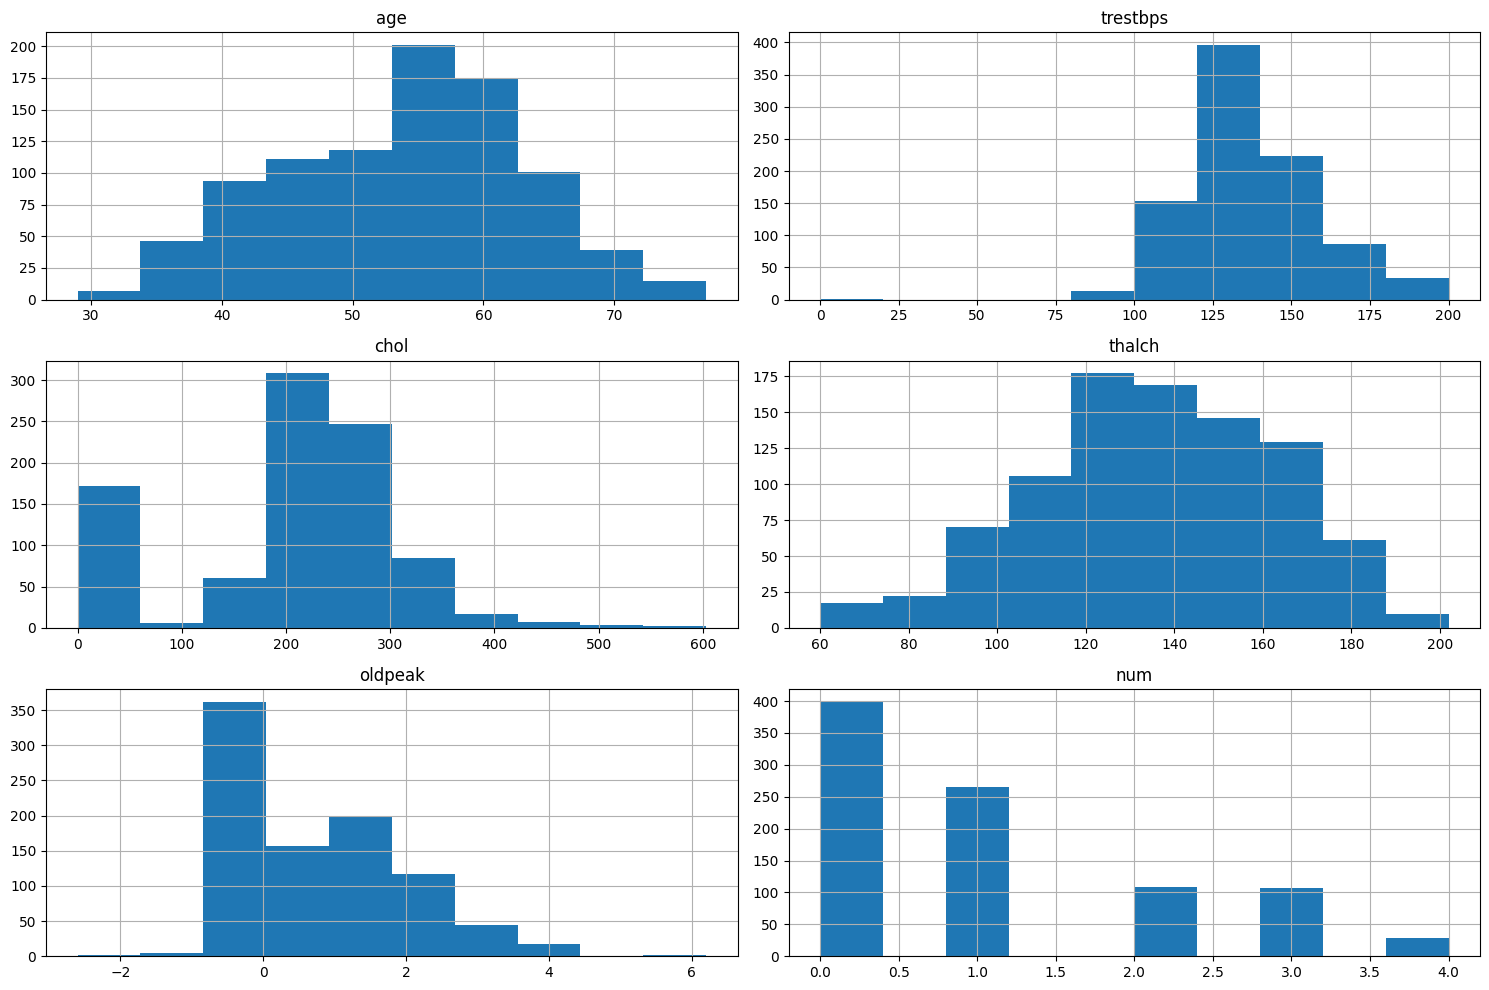

In [28]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

### Box Plot (Outlier Detection)

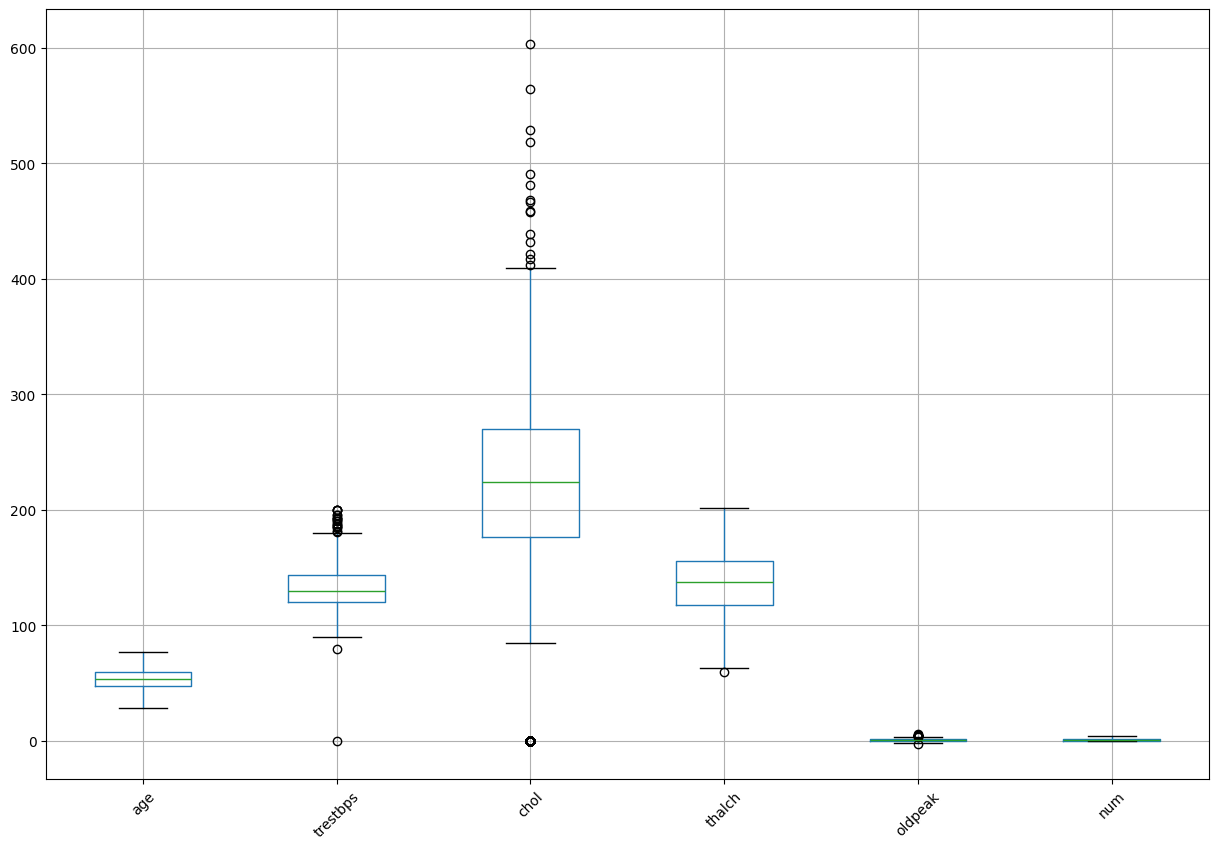

In [29]:
plt.figure(figsize=(15,10))

df.boxplot()

plt.xticks(rotation=45)
plt.show()

### Outlier Treatment Using IQR Method

In [30]:
Q1 = df.quantile(numeric_only=True, q=0.25)

Q3 = df.quantile(numeric_only=True, q=0.75)

IQR = Q3 - Q1

df = df[
    ~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
      (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)
]

df.shape

(692, 13)

### Correlation Matrix

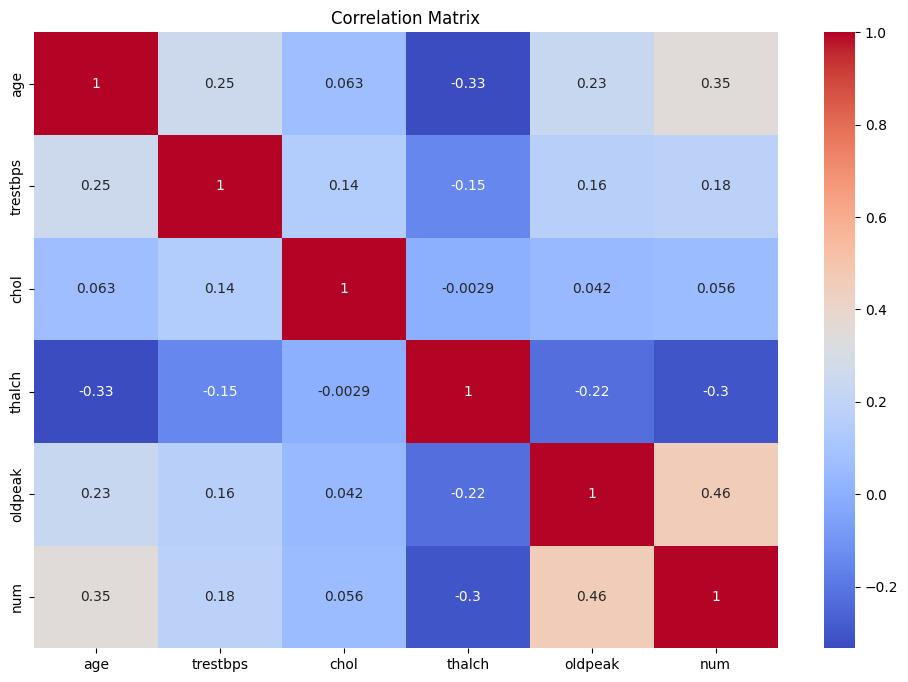

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

### Convert boolean to string

In [33]:
df['fbs'] = df['fbs'].astype(str)

df['exang'] = df['exang'].astype(str)

### Encode Categorical Variables

###### Machine learning models require numerical input, so categorical variables must be converted into numeric form using Label Encoding.

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

### Define Features and Target

In [35]:
X = df.drop('num', axis=1)

y = df['num']

### Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(553, 12)
(139, 12)


### Implement Decision Tree Classifier

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### Model Prediction

In [38]:
y_pred = dt_model.predict(X_test)

### Model Evaluation

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test,
                      y_pred,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test,
                   y_pred,
                   average='weighted',
                   zero_division=0))

print("F1 Score:",
      f1_score(y_test,
               y_pred,
               average='weighted',
               zero_division=0))

print(classification_report(y_test, y_pred))

Accuracy: 0.539568345323741
Precision: 0.5552848026211108
Recall: 0.539568345323741
F1 Score: 0.5470795206484916
              precision    recall  f1-score   support

           0       0.77      0.74      0.76        82
           1       0.37      0.37      0.37        30
           2       0.07      0.10      0.08        10
           3       0.15      0.14      0.15        14
           4       0.00      0.00      0.00         3

    accuracy                           0.54       139
   macro avg       0.27      0.27      0.27       139
weighted avg       0.56      0.54      0.55       139



### ROC-AUC Score

###### Since this is a multiclass classification problem, we use the One-vs-Rest (OVR) approach.

In [40]:
y_prob = dt_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5652490830930623


### Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


### Train Best Decision Tree Model

In [42]:
best_dt = grid.best_estimator_

best_dt.fit(X_train, y_train)

best_pred = best_dt.predict(X_test)

### Evaluate Tuned Model

In [43]:
print("Accuracy:",
      accuracy_score(y_test, best_pred))

print("Precision:",
      precision_score(y_test,
                      best_pred,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test,
                   best_pred,
                   average='weighted',
                   zero_division=0))

print("F1 Score:",
      f1_score(y_test,
               best_pred,
               average='weighted',
               zero_division=0))

Accuracy: 0.6546762589928058
Precision: 0.5252147796326045
Recall: 0.6546762589928058
F1 Score: 0.5828009828009828


### Visualize Decision Tree Structure

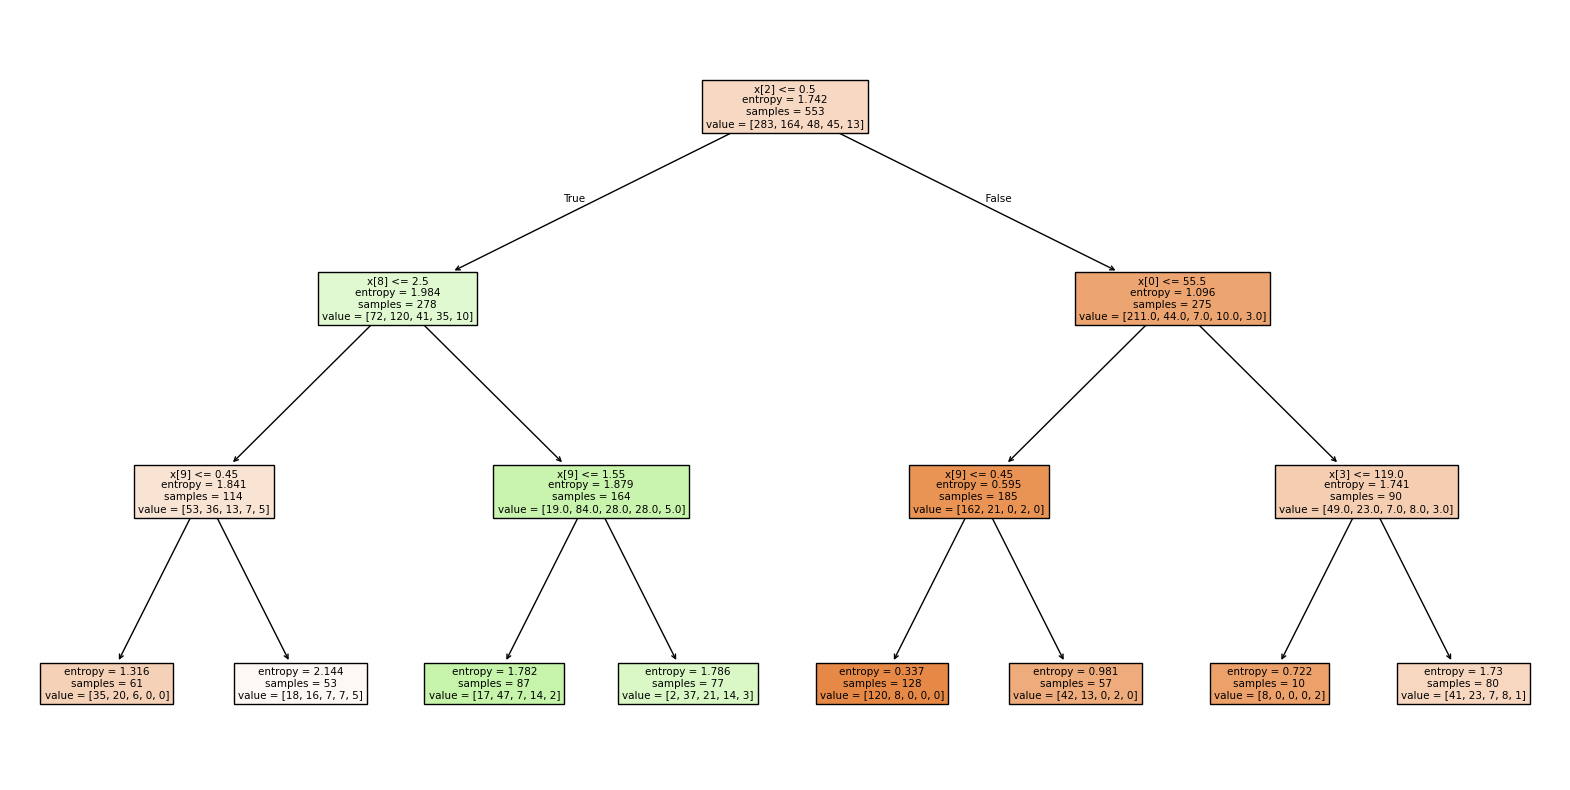

In [44]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    best_dt,
    filled=True
)

plt.show()

### Feature Importance

In [45]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.475609
9    oldpeak    0.183047
0        age    0.149295
8      exang    0.144393
3   trestbps    0.047656
1        sex    0.000000
4       chol    0.000000
5        fbs    0.000000
7     thalch    0.000000
6    restecg    0.000000
10     slope    0.000000
11      thal    0.000000


### Visualize Important Features

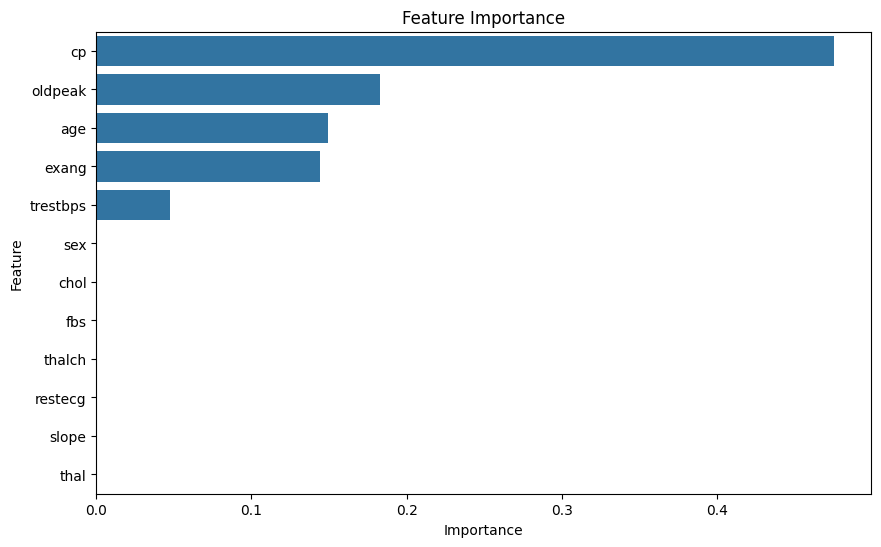

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# Analysis:

###### 1. Decision Tree classifies data based on feature splitting rules.
###### 2. Hyperparameter tuning improved model performance and reduced overfitting.
###### 3. Important features contribute more to prediction decisions.
###### 4. ROC-AUC score indicates the model's ability to distinguish between classes.
###### 5. Decision Tree visualization helps interpret learned decision rules.

# Interview Questions:

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

##### Common hyperparameters of Decision Tree models include:

##### max_depth:
###### Controls the maximum depth of the tree. Smaller depth reduces overfitting, while larger depth may improve training accuracy but increase overfitting.
##### min_samples_split:
###### Defines the minimum number of samples required to split a node. Higher values reduce complexity and overfitting.
##### criterion:
###### Measures the quality of a split. Common options are gini and entropy.
##### min_samples_leaf:
###### Specifies the minimum number of samples required at a leaf node. Helps smooth the model.

#### 2. What is the difference between the Label encoding and One-hot encoding?

##### Label Encoding

###### Label Encoding converts categorical values into numerical labels.

##### Example:

###### Male -> 0
###### Female -> 1

###### It is suitable when categories have an ordinal relationship.

##### One-Hot Encoding

###### One-Hot Encoding creates separate binary columns for each category.

##### Example:

###### Red -> [1,0,0]
###### Blue -> [0,1,0]

###### It is preferred when categories do not have an ordinal relationship.